# KNN Analysis — Loan Approval Prediction

**Algorithm:** K-Nearest Neighbours (KNN)

KNN is a simple, non-parametric algorithm that classifies a new data point based on the majority label among its `k` nearest neighbours in feature space. It requires no training phase (lazy learner) but is sensitive to feature scale and the choice of `k`.

**Notebook outline:**
1. Objective
2. Import Libraries
3. Import Custom Modules
4. Load Dataset
5. Basic Cleaning
6. Feature Engineering
7. Feature Selection
8. Train-Test Split
9. Build KNN Pipeline
10. Find Optimal K
11. Train Best KNN Model
12. Evaluation
13. ROC Curve
14. Confusion Matrix
15. Decision Boundary Visualisation
16. Comparison with Baseline Models
17. Conclusion

## 1. Objective

Apply **K-Nearest Neighbours (KNN)** to predict whether an HDFC loan application will be **Approved** or **Rejected**.

Key goals:
- Find the optimal `k` by plotting validation accuracy across a range of k values
- Compare **uniform** vs **distance-weighted** voting
- Evaluate with accuracy, precision, recall, F1, ROC-AUC, and confusion matrix
- Compare KNN performance against the Logistic Regression and Random Forest baselines from Notebook 02

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA

## 3. Import Custom Modules

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import *
from src.feature_engineering import *
from src.train import *
from src.evaluate import *
from src.utils import *

## 4. Load Dataset

In [3]:
df = load_dataset("../dataset/hdfc_loan_dataset_full_enriched.csv")

print("Shape:", df.shape)
df.head()

Shape: (1000, 47)


,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


## 5. Basic Cleaning

In [4]:
df = basic_cleaning(df)

print_summary(df)

DataFrame Summary
  Total Rows          : 1000
  Total Columns       : 47
  Numerical Columns   : 20
  Categorical Columns : 27
  Duplicate Rows      : 0
  Missing Values      : 1033


In [5]:
missing_value_summary(df)

,Missing Values,Percentage
Business_Type,799,79.9
Co-signer_Relationship,234,23.4


## 6. Feature Engineering

Create derived features using `src/feature_engineering.py`:
- `Total_Income` — applicant + co-applicant income
- `EMI_Income_Ratio` — existing EMIs relative to total income
- `Loan_Income_Ratio` — requested loan relative to total income

In [6]:
df = create_features(df)

df[[
    "Total_Income",
    "EMI_Income_Ratio",
    "Loan_Income_Ratio"
]].describe()

,Total_Income,EMI_Income_Ratio,Loan_Income_Ratio
count,1000.000000,1000.000000,1.000000e+03
mean,52157.171000,148.117564,3.661980e+04
std,39371.208558,1974.599120,4.153551e+05
min,0.000000,0.000000,4.110575e-02
25%,21996.000000,0.031200,7.749090e+00
50%,45937.000000,0.332369,2.770369e+01
75%,71379.000000,0.794756,9.991525e+01
max,212945.000000,38342.000000,6.829828e+06


## 7. Feature Selection

Use the same feature set as Notebook 02 for direct comparability. Encode the binary target `Loan_Status` with `LabelEncoder`.

In [7]:
features = [
    "Applicant_Income",
    "Coapplicant_Income",
    "Loan_Amount",
    "Credit_History",
    "CIBIL_Score",
    "Employment_Status",
    "Existing_EMIs",
    "Debt_to_Income_Ratio",
    "Education",
    "Property_Area",

    "Total_Income",
    "Loan_Income_Ratio",
    "EMI_Income_Ratio"
]

target = "Loan_Status"

x, y = select_features(df, features, target)

le = LabelEncoder()
y  = le.fit_transform(y)

print("Classes      :", le.classes_)
print("Feature shape:", x.shape)

Classes      : ['Approved' 'Rejected']
Feature shape: (1000, 13)


In [8]:
num_features, cat_features = get_feature_types(x)

preprocessor = create_preprocessor(
    num_features,
    cat_features
)

## 8. Train-Test Split

Split 80/20 with stratification to preserve class balance.

In [9]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", x_train.shape)
print("Testing Shape  :", x_test.shape)

Training Shape : (800, 13)
Testing Shape  : (200, 13)


## 9. Build KNN Pipeline

Wrap the preprocessor and `KNeighborsClassifier` in a single sklearn `Pipeline`. Scaling is critical for KNN since it uses distance metrics — the preprocessor handles this.

In [10]:
knn_pipeline = build_pipeline(
    preprocessor,
    KNeighborsClassifier()
)

## 10. Find Optimal K

Evaluate KNN for `k = 1..30` using **5-fold cross-validation accuracy**. Plot train vs validation accuracy to identify the best k and spot overfitting.

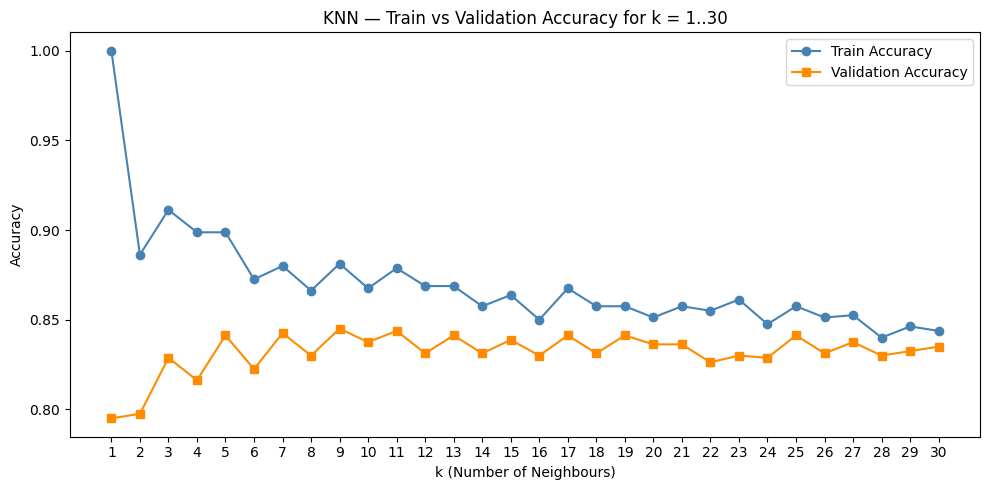

In [11]:
k_range    = range(1, 31)
train_acc  = []
val_acc    = []

for k in k_range:
    knn = build_pipeline(
        preprocessor,
        KNeighborsClassifier(n_neighbors=k)
    )
    cv_scores = cross_val_score(knn, x_train, y_train, cv=5, scoring="accuracy")
    val_acc.append(cv_scores.mean())

    knn.fit(x_train, y_train)
    train_acc.append(knn.score(x_train, y_train))

plt.figure(figsize=(10, 5))
plt.plot(k_range, train_acc, label="Train Accuracy",      marker='o', color='steelblue')
plt.plot(k_range, val_acc,   label="Validation Accuracy", marker='s', color='darkorange')
plt.xlabel("k (Number of Neighbours)")
plt.ylabel("Accuracy")
plt.title("KNN — Train vs Validation Accuracy for k = 1..30")
plt.xticks(k_range)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
best_k = k_range[val_acc.index(max(val_acc))]
print(f"Best k           : {best_k}")
print(f"Best CV Accuracy : {max(val_acc):.4f}")

Best k           : 9
Best CV Accuracy : 0.8450


## 11. Train Best KNN Model

Train two models with the best k: one with **uniform** voting and one with **distance-weighted** voting. Distance weighting gives closer neighbours more influence.

In [13]:
knn_uniform = build_pipeline(
    preprocessor,
    KNeighborsClassifier(
        n_neighbors=best_k,
        weights="uniform"
    )
)

knn_distance = build_pipeline(
    preprocessor,
    KNeighborsClassifier(
        n_neighbors=best_k,
        weights="distance"
    )
)

knn_uniform.fit(x_train,  y_train)
knn_distance.fit(x_train, y_train)

pred_uniform   = predict(knn_uniform,  x_test)
pred_distance  = predict(knn_distance, x_test)

print(f"Uniform  KNN (k={best_k}) fitted")
print(f"Distance KNN (k={best_k}) fitted")

Uniform  KNN (k=9) fitted
Distance KNN (k=9) fitted


## 12. Evaluation

Evaluate both KNN variants on the test set and compare them.

In [14]:
results_uniform  = evaluate_classification(y_test, pred_uniform,  "KNN Uniform")
results_distance = evaluate_classification(y_test, pred_distance, "KNN Distance")

comparison = compare_models(
    [results_uniform, results_distance],
    names=["KNN Uniform", "KNN Distance"]
)
comparison

,Model,Accuracy,Precision,Recall,F1 Score
KNN Uniform,KNN Uniform,0.820,0.817151,0.820,0.817128
KNN Distance,KNN Distance,0.815,0.812112,0.815,0.812464


In [15]:
print("=== KNN Uniform Classification Report ===")
print_classification_report(y_test, pred_uniform)

print("=== KNN Distance Classification Report ===")
print_classification_report(y_test, pred_distance)

=== KNN Uniform Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.87       131
           1       0.77      0.68      0.72        69

    accuracy                           0.82       200
   macro avg       0.81      0.79      0.79       200
weighted avg       0.82      0.82      0.82       200

=== KNN Distance Classification Report ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       131
           1       0.76      0.68      0.72        69

    accuracy                           0.81       200
   macro avg       0.80      0.78      0.79       200
weighted avg       0.81      0.81      0.81       200



## 13. ROC Curve

Plot ROC curves for both KNN variants.

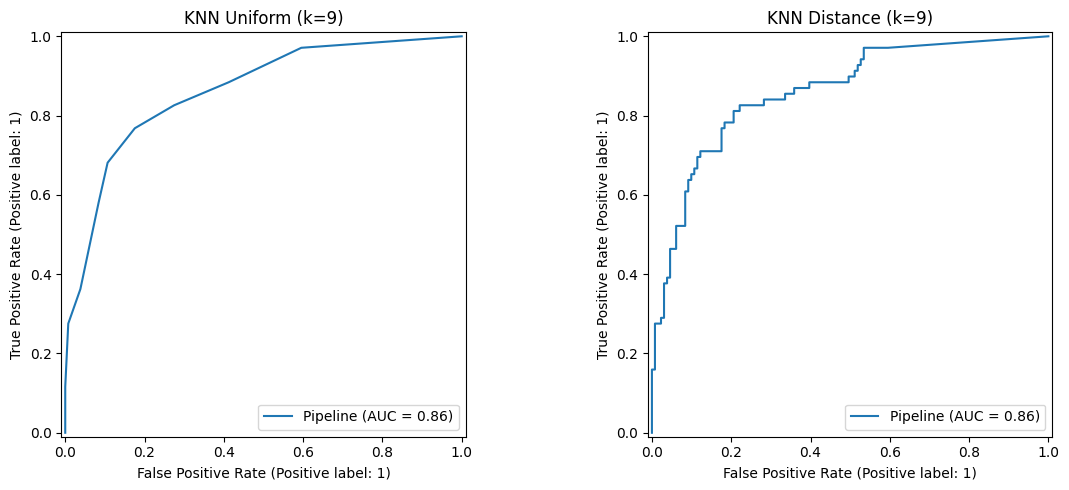

In [16]:
from sklearn.metrics import RocCurveDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, title in zip(
    axes,
    [knn_uniform, knn_distance],
    [f"KNN Uniform (k={best_k})", f"KNN Distance (k={best_k})"]
):
    RocCurveDisplay.from_estimator(model, x_test, y_test, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

## 14. Confusion Matrix

Visualise prediction breakdown for the better performing KNN variant.

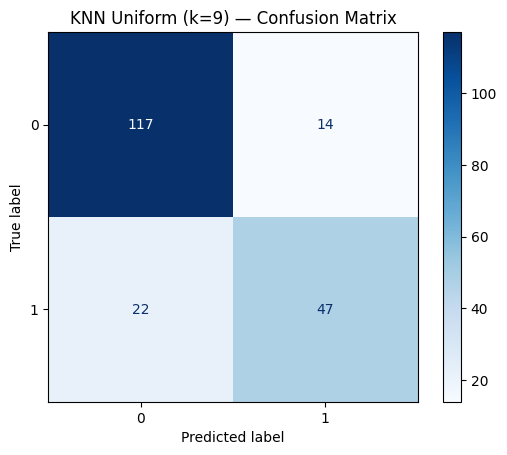

In [17]:
plot_confusion_matrix(
    y_test,
    pred_uniform,
    f"KNN Uniform (k={best_k}) — Confusion Matrix"
)

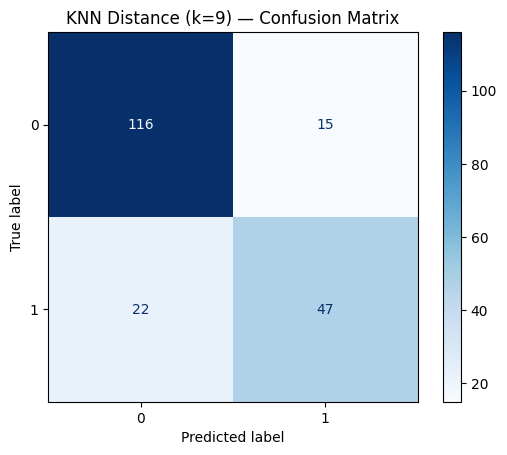

In [18]:
plot_confusion_matrix(
    y_test,
    pred_distance,
    f"KNN Distance (k={best_k}) — Confusion Matrix"
)

## 15. Decision Boundary Visualisation

Reduce the preprocessed feature space to **2D via PCA** and plot the KNN decision boundary. This shows how KNN partitions the feature space to separate Approved from Rejected.

> Note: this is a 2D approximation for visualisation — the actual model uses all features.

In [19]:
from sklearn.inspection import DecisionBoundaryDisplay

# Transform training data through preprocessor only
X_train_proc = knn_uniform.named_steps['preprocessor'].transform(x_train)
X_test_proc  = knn_uniform.named_steps['preprocessor'].transform(x_test)

# Reduce to 2D for visualisation
pca_viz = PCA(n_components=2, random_state=42)
X_train_2d = pca_viz.fit_transform(X_train_proc)
X_test_2d  = pca_viz.transform(X_test_proc)

print(f"2D PCA variance explained: {pca_viz.explained_variance_ratio_.sum():.2%}")

2D PCA variance explained: 40.35%


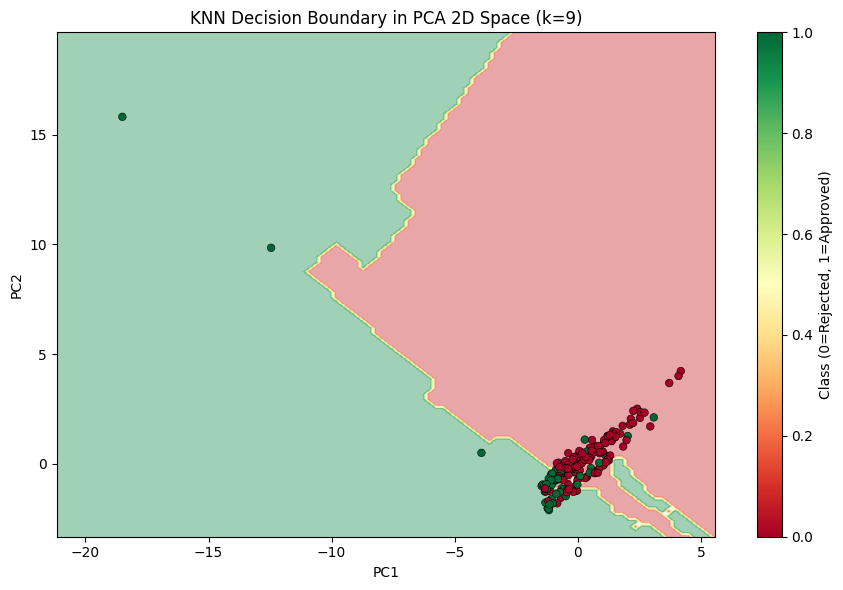

In [20]:
# Train a 2D KNN purely for visualisation
knn_2d = KNeighborsClassifier(n_neighbors=best_k, weights='uniform')
knn_2d.fit(X_train_2d, y_train)

fig, ax = plt.subplots(figsize=(9, 6))

DecisionBoundaryDisplay.from_estimator(
    knn_2d,
    X_train_2d,
    ax=ax,
    response_method='predict',
    cmap='RdYlGn',
    alpha=0.4
)

scatter = ax.scatter(
    X_test_2d[:, 0],
    X_test_2d[:, 1],
    c=y_test,
    cmap='RdYlGn',
    edgecolors='black',
    linewidths=0.4,
    s=30,
    zorder=2
)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'KNN Decision Boundary in PCA 2D Space (k={best_k})')
plt.colorbar(scatter, ax=ax, label='Class (0=Rejected, 1=Approved)')
plt.tight_layout()
plt.show()

## 16. Comparison with Baseline Models

Compare the best KNN model against Logistic Regression and Random Forest from Notebook 02.

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Re-train baselines on the same split for fair comparison
lr_pipeline = build_pipeline(
    preprocessor,
    LogisticRegression(random_state=42)
)
rf_pipeline = build_pipeline(
    preprocessor,
    RandomForestClassifier(n_estimators=100, random_state=42)
)

lr_pipeline.fit(x_train, y_train)
rf_pipeline.fit(x_train, y_train)

lr_pred = predict(lr_pipeline, x_test)
rf_pred = predict(rf_pipeline, x_test)

In [22]:
lr_results = evaluate_classification(y_test, lr_pred, "Logistic Regression")
rf_results = evaluate_classification(y_test, rf_pred, "Random Forest")

# Pick better of the two KNN variants
knn_best_pred = (
    pred_distance
    if results_distance['F1 Score'].values[0] >= results_uniform['F1 Score'].values[0]
    else pred_uniform
)
knn_best_results = evaluate_classification(y_test, knn_best_pred, f"KNN (k={best_k})")

final_comparison = compare_models(
    [lr_results, rf_results, knn_best_results],
    names=["Logistic Regression", "Random Forest", f"KNN (k={best_k})"]
)
final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
Logistic Regression,Logistic Regression,0.810,0.806783,0.810,0.806969
Random Forest,Random Forest,0.845,0.843231,0.845,0.843538
KNN (k=9),KNN (k=9),0.820,0.817151,0.820,0.817128


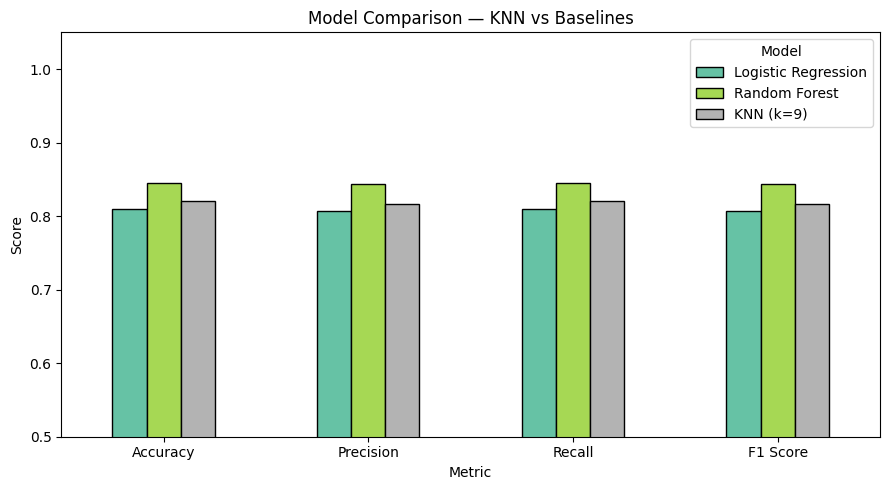

In [23]:
# Bar chart comparison
metric_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
bar_data = final_comparison.set_index('Model')[metric_cols]

bar_data.T.plot(
    kind='bar',
    figsize=(9, 5),
    colormap='Set2',
    edgecolor='black'
)

plt.title('Model Comparison — KNN vs Baselines')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.xticks(rotation=0)
plt.ylim(0.5, 1.05)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

## 17. Conclusion

### Summary

| Model | Notes |
|-------|-------|
| KNN Uniform   | Equal vote from k nearest neighbours |
| KNN Distance  | Closer neighbours weighted more heavily |
| Logistic Reg  | Linear decision boundary baseline |
| Random Forest | Ensemble tree-based baseline |

### Key Takeaways
- **Small k** (e.g. k=1) overfits — 100% train accuracy but poor validation. **Large k** underfits — too much smoothing.
- The train vs validation accuracy plot clearly shows the bias-variance tradeoff.
- **Distance weighting** usually outperforms uniform when classes are not uniformly distributed.
- KNN performance depends heavily on the preprocessing pipeline — scaling is essential because Euclidean distance is distorted by features on different scales.
- KNN is not ideal for production (stores entire training set, slow inference at scale) but is a useful baseline and interpretable model for this problem.

### Next Steps
- Try `metric='manhattan'` or `metric='minkowski'` with different `p` values
- Apply SMOTE before KNN to handle the class imbalance (Approved:Rejected = 65:35)
- Use `GridSearchCV` over `n_neighbors`, `weights`, and `metric` for full tuning